In [1]:
import tarfile
import gzip
from pathlib import Path

import pandas as pd
import scanpy as sc
import anndata as ad
from scipy import sparse

# =========================================================
# Paths
# =========================================================
base_dir = Path(r"C:/Users/ankit/Documents/scFM/train_data/GSE202379_from_TAR")
tar_path = base_dir / "GSE202379_RAW.tar"
extract_dir = base_dir / "extracted_raw"
output_h5ad = base_dir / "GSE202379_selected_raw.h5ad"

In [6]:
import tarfile
import gzip
from pathlib import Path

import pandas as pd
import scanpy as sc
import anndata as ad
from scipy import sparse

# =========================================================
# Paths
# =========================================================
base_dir = Path(r"C:/Users/ankit/Documents/scFM/train_data/GSE202379_from_TAR")
tar_path = base_dir / "GSE202379_RAW.tar"
extract_dir = base_dir / "extracted_raw"
output_h5ad = base_dir / "GSE202379_selected_raw.h5ad"

# =========================================================
# GSMs to keep
# =========================================================
gsm_to_title = {
    "GSM6112209": "P70-NASH w/o cirrhosis-B-SITTA3",
    "GSM6112210": "P48-NASH w/o cirrhosis-B-SITTA8",
    "GSM6112211": "P77-NASH w/o cirrhosis-B-SITTB8",
    "GSM6112212": "P78-NAFLD-B-SITTC8",
    "GSM6112213": "P62-NASH w/o cirrhosis-B-SITTD3",
    "GSM6112214": "P12-NASH with cirrhosis-B-SITTD8",
    "GSM6112215": "P22-NASH with cirrhosis-B-SITTE8",
    "GSM6112216": "P83-NASH w/o cirrhosis-B-SITTF12",
    "GSM6112217": "P67-NASH w/o cirrhosis-B-SITTF3",
    "GSM6112218": "P52-NASH w/o cirrhosis-C-SITTD9",
    "GSM6112219": "P53-NASH w/o cirrhosis-C-SITTE9",
    "GSM6112220": "P54-NASH w/o cirrhosis-C-SITTF9",
    "GSM6112221": "P71-NASH w/o cirrhosis-C-SITTG1",
    "GSM6112222": "P64-NASH w/o cirrhosis-D-SITTA6",
    "GSM6112223": "P6-NAFLD-D-SITTA7",
    "GSM6112224": "P49-NASH w/o cirrhosis-D-SITTA9",
    "GSM6112225": "P50-NASH w/o cirrhosis-D-SITTB9",
    "GSM6112226": "P51-NAFLD-D-SITTC9",
    "GSM6112227": "P68-NASH with cirrhosis-D-SITTD5",
    "GSM6112228": "P75-NASH with cirrhosis-D-SITTE5",
    "GSM6112229": "P76-NASH w/o cirrhosis-D-SITTF5",
    "GSM6112230": "P60-NAFLD-D-SITTG5",
    "GSM6112231": "P7-NASH w/o cirrhosis-E-SITTB5",
    "GSM6112232": "P19-NASH w/o cirrhosis-E-SITTB6",
    "GSM6112233": "P8-NASH w/o cirrhosis-E-SITTC5",
    "GSM6112234": "P20-NASH w/o cirrhosis-E-SITTC6",
    "GSM6112235": "P9-NASH w/o cirrhosis-E-SITTD5",
    "GSM6112236": "P21-NASH w/o cirrhosis-E-SITTD6",
    "GSM6112237": "PHL2-Healthy control-E-SITTD9",
    "GSM6112239": "P15-NASH w/o cirrhosis-E-SITTF5",
    "GSM6112241": "P16-NASH w/o cirrhosis-E-SITTG5",
    "GSM6112243": "P30-Healthy control-G-SITTB7",
    "GSM6112244": "P98-Healthy control-G-SITTF7",
    "GSM6112251": "P57-NASH w/o cirrhosis-SIGAA4",
    "GSM6112252": "P11-NASH w/o cirrhosis-SIGAH11",
    "GSM6112253": "P3-NASH w/o cirrhosis-SIGAH3",
    "GSM6112255": "P55-NAFLD-SITTA5",
    "GSM6112256": "P56-NAFLD-SITTB5",
    "GSM6112257": "PHL1-Healthy control-SITTC1",
    "GSM6112259": "P72-NASH w/o cirrhosis-SITTC3",
    "GSM6112260": "PHL1-Healthy control-SITTD1",
    "GSM6112261": "P73-NASH w/o cirrhosis-SITTD3",
    "GSM6112263": "PHL1-Healthy control-SITTE1",
    "GSM6112266": "P84-NAFLD-SITTG12",
}
wanted_gsms = set(gsm_to_title.keys())

# =========================================================
# Helpers
# =========================================================
def extract_tar_if_needed(tar_path: Path, extract_dir: Path):
    extract_dir.mkdir(parents=True, exist_ok=True)
    if any(extract_dir.iterdir()):
        print(f"[INFO] Already extracted: {extract_dir}")
        return
    print(f"[INFO] Extracting {tar_path} ...")
    with tarfile.open(tar_path, "r") as tar:
        tar.extractall(path=extract_dir)
    print("[INFO] Extraction complete.")

def parse_sample_title(title: str):
    patient_id = title.split("-")[0]

    if "NASH with cirrhosis" in title:
        diagnosis = "NASH w Cirrhosis"
    elif "NASH w/o cirrhosis" in title:
        diagnosis = "NASH w/o cirrhosis"
    elif "NAFLD" in title:
        diagnosis = "NAFLD"
    elif "Healthy control" in title:
        diagnosis = "Healthy"
    else:
        diagnosis = "Unknown"

    return patient_id, diagnosis

def load_raw_counts_csv(path: Path):
    # genes as rows, cells as columns
    df = pd.read_csv(path, sep=",", index_col=0, compression="gzip")

    # convert to sparse matrix, cells x genes
    X = sparse.csr_matrix(df.values.T)

    adata = ad.AnnData(
        X=X,
        obs=pd.DataFrame(index=df.columns.astype(str)),
        var=pd.DataFrame(index=df.index.astype(str))
    )
    adata.var.index.name = "gene_symbol"
    return adata



In [ ]:
# =========================================================
# Main
# =========================================================
extract_tar_if_needed(tar_path, extract_dir)

all_raw_files = sorted(extract_dir.glob("*raw_counts.csv.gz"))
print(f"[INFO] Found {len(all_raw_files)} raw count files total")

selected_files = []
for f in all_raw_files:
    gsm = f.name.split("_")[0]
    if gsm in wanted_gsms:
        selected_files.append(f)

print(f"[INFO] Found {len(selected_files)} selected raw count files")

missing = sorted(wanted_gsms - {f.name.split('_')[0] for f in selected_files})
if missing:
    print("[WARNING] Missing wanted GSM files:")
    for gsm in missing:
        print("   ", gsm)

adatas = []

for f in selected_files:
    gsm = f.name.split("_")[0]
    title = gsm_to_title[gsm]

    print(f"[INFO] Loading {f.name}")
    adata = load_raw_counts_csv(f)

    # make cell barcodes unique across samples
    adata.obs_names = [f"{gsm}_{bc}" for bc in adata.obs_names]

    patient_id, diagnosis = parse_sample_title(title)

    adata.obs["gsm_id"] = gsm
    adata.obs["sample_title"] = title
    adata.obs["patient_id"] = patient_id
    adata.obs["diagnosis"] = diagnosis
    adata.layers["counts"] = adata.X.copy()

    adatas.append(adata)

if len(adatas) == 0:
    raise RuntimeError("No selected samples were loaded.")

print("[INFO] Concatenating...")
adata = ad.concat(
    adatas,
    join="outer",
    merge="same",
    fill_value=0
)

if not sparse.issparse(adata.X):
    adata.X = sparse.csr_matrix(adata.X)

adata.layers["counts"] = adata.X.copy()
adata.var_names_make_unique()





[INFO] Already extracted: C:\Users\ankit\Documents\scFM\train_data\GSE202379_from_TAR\extracted_raw
[INFO] Found 59 raw count files total
[INFO] Found 44 selected raw count files
[INFO] Loading GSM6112209_B-SITTA3-raw_counts.csv.gz
[INFO] Loading GSM6112210_B-SITTA8-raw_counts.csv.gz
[INFO] Loading GSM6112211_B-SITTB8-raw_counts.csv.gz
[INFO] Loading GSM6112212_B-SITTC8-raw_counts.csv.gz
[INFO] Loading GSM6112213_B-SITTD3-raw_counts.csv.gz
[INFO] Loading GSM6112214_B-SITTD8-raw_counts.csv.gz
[INFO] Loading GSM6112215_B-SITTE8-raw_counts.csv.gz
[INFO] Loading GSM6112216_B-SITTF12-raw_counts.csv.gz
[INFO] Loading GSM6112217_B-SITTF3-raw_counts.csv.gz
[INFO] Loading GSM6112218_C-SITTD9-raw_counts.csv.gz
[INFO] Loading GSM6112219_C-SITTE9-raw_counts.csv.gz
[INFO] Loading GSM6112220_C-SITTF9-raw_counts.csv.gz
[INFO] Loading GSM6112221_C-SITTG1-raw_counts.csv.gz
[INFO] Loading GSM6112222_D-SITTA6-raw_counts.csv.gz
[INFO] Loading GSM6112223_D-SITTA7-raw_counts.csv.gz
[INFO] Loading GSM6112224

KeyError: 'cirrhosis_status'

In [8]:
print(adata)
print("\n[INFO] Diagnosis counts:")
print(adata.obs["diagnosis"].value_counts())

print("\n[INFO] Number of GSM samples kept:")
print(adata.obs["gsm_id"].nunique())

AnnData object with n_obs × n_vars = 68319 × 31257
    obs: 'gsm_id', 'sample_title', 'patient_id', 'diagnosis'
    layers: 'counts'

[INFO] Diagnosis counts:
diagnosis
NASH w/o cirrhosis    45530
NAFLD                 10388
Healthy                7104
NASH w Cirrhosis       5297
Name: count, dtype: int64

[INFO] Number of GSM samples kept:
44


In [11]:
print(f"\n[INFO] Saving to: {output_h5ad}")
adata.write_h5ad(output_h5ad, compression="gzip")
print("[INFO] Done.")


[INFO] Saving to: C:\Users\ankit\Documents\scFM\train_data\GSE202379_from_TAR\GSE202379_selected_raw.h5ad
[INFO] Done.


In [2]:
# Read in the saved file to verify
print(f"\n[INFO] Reading back saved file: {output_h5ad}")
adata = sc.read_h5ad(output_h5ad)
print(adata)


[INFO] Reading back saved file: C:\Users\ankit\Documents\scFM\train_data\GSE202379_from_TAR\GSE202379_selected_raw.h5ad
AnnData object with n_obs × n_vars = 68319 × 31257
    obs: 'gsm_id', 'sample_title', 'patient_id', 'diagnosis', 'disease_status', 'saf_score', 'sex', 'age', 'bmi', 'ethnic_group', 's_score', 'a_score', 'f_score'
    layers: 'counts'


In [8]:
for x in adata.obs["patient_id"].unique():
    print(x)

P70
P48
P77
P78
P62
P12
P22
P83
P67
P52
P53
P54
P71
P64
P6
P49
P50
P51
P68
P75
P76
P60
P7
P19
P8
P20
P9
P21
PHL2
P15
P16
P30
P98
P57
P11
P3
P55
P56
PHL1
P72
P73
P84


In [9]:
# Read in additional metadata file "additional_meta.csv"
additional_meta = pd.read_csv(base_dir / "additional_meta.csv")
print("\n[INFO] Additional metadata:")
print(additional_meta.head())


[INFO] Additional metadata:
  patient_id      disease_status saf_score sex  age    bmi   ethnic_group  \
0         P3  MASH w/o cirrhosis    S2A3F1   M   56  38.01  White British   
1         P6  MASH w/o cirrhosis    S2A3F1   M   46  41.86  White British   
2         P7  MASH w/o cirrhosis    S3A4F2   M   47  34.46  White British   
3         P8  MASH w/o cirrhosis    S2A4F3   M   65  32.46  White British   
4         P9  MASH w/o cirrhosis    S2A2F1   M   50  36.68  White British   

   s_score  a_score  f_score  
0      2.0      3.0      1.0  
1      2.0      3.0      1.0  
2      3.0      4.0      2.0  
3      2.0      4.0      3.0  
4      2.0      2.0      1.0  


In [10]:
# Merge additional metadata into adata.obs based on patient_id
adata.obs = adata.obs.merge(additional_meta, on="patient_id", how="left")
print("\n[INFO] adata.obs after merging additional metadata:")
print(adata.obs.head())


[INFO] adata.obs after merging additional metadata:
       gsm_id                     sample_title patient_id           diagnosis  \
0  GSM6112209  P70-NASH w/o cirrhosis-B-SITTA3        P70  NASH w/o cirrhosis   
1  GSM6112209  P70-NASH w/o cirrhosis-B-SITTA3        P70  NASH w/o cirrhosis   
2  GSM6112209  P70-NASH w/o cirrhosis-B-SITTA3        P70  NASH w/o cirrhosis   
3  GSM6112209  P70-NASH w/o cirrhosis-B-SITTA3        P70  NASH w/o cirrhosis   
4  GSM6112209  P70-NASH w/o cirrhosis-B-SITTA3        P70  NASH w/o cirrhosis   

       disease_status saf_score sex   age    bmi   ethnic_group  s_score  \
0  MASH w/o cirrhosis    S2A3F3   M  59.0  35.49  White British      2.0   
1  MASH w/o cirrhosis    S2A3F3   M  59.0  35.49  White British      2.0   
2  MASH w/o cirrhosis    S2A3F3   M  59.0  35.49  White British      2.0   
3  MASH w/o cirrhosis    S2A3F3   M  59.0  35.49  White British      2.0   
4  MASH w/o cirrhosis    S2A3F3   M  59.0  35.49  White British      2.0   

   

c:\Users\ankit\miniconda3\envs\scanpy\Lib\functools.py:982: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


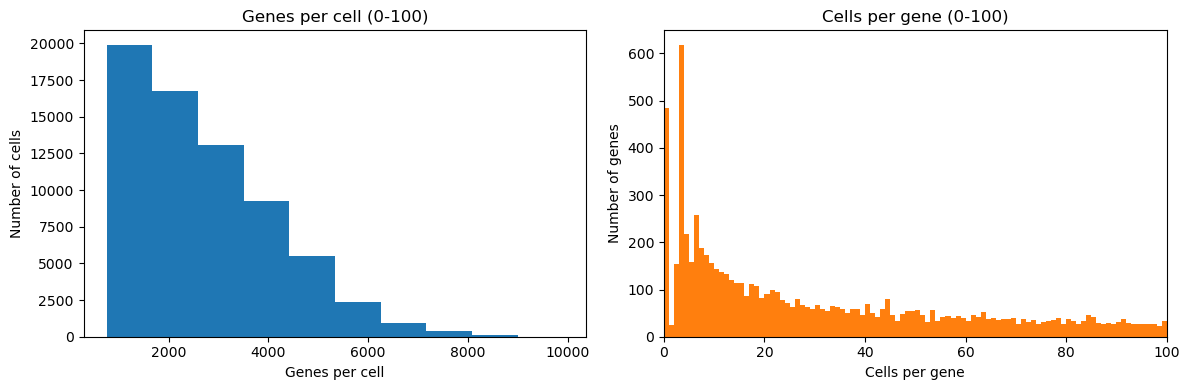

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import sparse

X = adata.X

if sparse.issparse(X):
    X = X.tocsc()
    genes_per_cell = np.asarray((X > 0).sum(axis=1)).ravel()
    cells_per_gene = np.asarray((X > 0).sum(axis=0)).ravel()
else:
    genes_per_cell = np.sum(X > 0, axis=1)
    cells_per_gene = np.sum(X > 0, axis=0)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(genes_per_cell)#, bins=np.arange(0, 102), color="C0")#,=(0, 100))
#axes[0].set_xlim(0, 100)
axes[0].set_xlabel("Genes per cell")
axes[0].set_ylabel("Number of cells")
axes[0].set_title("Genes per cell (0-100)")

axes[1].hist(cells_per_gene, bins=np.arange(0, 102), range=(0, 100), color="C1")
axes[1].set_xlim(0, 100)
axes[1].set_xlabel("Cells per gene")
axes[1].set_ylabel("Number of genes")
axes[1].set_title("Cells per gene (0-100)")

plt.tight_layout()
plt.show()

In [11]:
# Determine the minimum and maximum number of genes per cell
min_genes_per_cell = np.min(genes_per_cell)
print(f"Minimum number of genes per cell: {min_genes_per_cell}")
# Determine how many cells have at least the minimum number of genes
num_cells_with_min_genes = np.sum(genes_per_cell >= min_genes_per_cell)
print(f"Number of cells with at least {min_genes_per_cell} genes: {num_cells_with_min_genes}")

Minimum number of genes per cell: 756
Number of cells with at least 756 genes: 68319
